In [19]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_qsphere
from qiskit.visualization import plot_bloch_multivector
from qiskit.visualization import plot_histogram
from qiskit_aer import Aer
from qiskit import transpile
from typing import Literal

## 1. Deutsch Algorithm

### 1.1 Problem Statement

Imagine there is a "black box" function (an oracle) that takes a single bit as input ($0$ or $1$) and outputs a single bit ($0$ or $1$). There are four possible functions:

- Constant Functions: The output is the same regardless of the input.$f(0) = 0$ and $f(1) = 0$, $f(0) = 1$ and $f(1) = 1$
- Balanced Functions: The output is $0$ for one input and $1$ for the other.$f(0) = 0$ and $f(1) = 1$, $f(0) = 1$ and $f(1) = 0$

The Goal is to determine if the function is constant or balanced.

##### Why is it better than Classical?

For Classical computing, it must check the function twice. You ask what $f(0)$ is, then what $f(1)$ is. Only then can you compare them. Using Quantum computing, for the Deutsch Algorithm, you only need to query the function once.

In [ ]:
class DeutschAlgorithm:

    def __init__(self, _type: Literal['constant_0', 'constant_1', 'balanced_x', 'balanced_notx'] = 'constant_0'):
        self.qc = QuantumCircuit(2, 1)

        # Prepare on both sides
        self.qc.h(0)
        self.qc.x(1)
        self.qc.h(1)
        self.type = _type
        self.qc.barrier(label='T0')
        self._oracle()
        self._end_superposition()
        self._computational_result()

    def _oracle(self):
        if self.type == 'constant_0':
            pass
        elif self.type == 'constant_1':
            self.qc.x(1)
        elif self.type == 'balanced_x':
            self.qc.cx(0, 1)
        elif self.type == 'balanced_notx':
            self.qc.cx(0, 1)
            self.qc.x(1)
        self.qc.barrier(label='T1')

    def _end_superposition(self):
        self.qc.h(0)
        self.qc.barrier(label="T2")

    def _computational_result(self):
        self.qc.measure(0, 0)

    def compute(self):
        qasm_simulator = Aer.get_backend('qasm_simulator')
        statevector_simulator = Aer.get_backend('statevector_simulator')
        compiled_circuit = transpile(self.qc, backend=qasm_simulator)
        job = statevector_simulator.run(compiled_circuit, shots=1024)
        return job.result().get_counts()

### 1.2 Constant Functions

For the end result, it should return $0$.

In [62]:
da1 = DeutschAlgorithm(_type='constant_0')
da2 = DeutschAlgorithm(_type='constant_1')

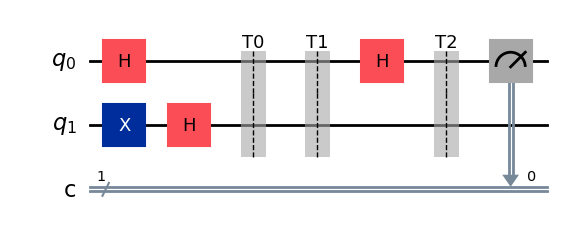

In [63]:
da1.qc.draw(output='mpl')

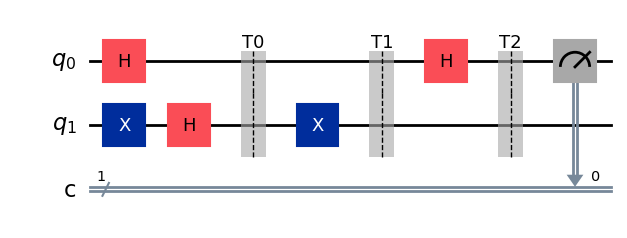

In [64]:
da2.qc.draw(output='mpl')

In [65]:
assert da1.compute() == da2.compute()
da1.compute()

{'0': 1024}

### 1.3 Balanced Functions

For the end result, it should return $1$.

In [66]:
da1 = DeutschAlgorithm(_type='balanced_x')
da2 = DeutschAlgorithm(_type='balanced_notx')

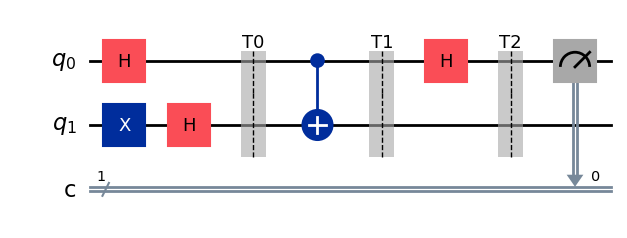

In [67]:
da1.qc.draw(output='mpl')

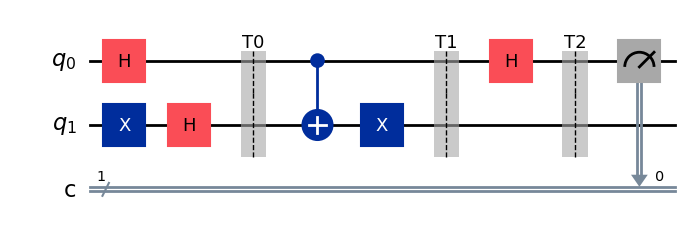

In [68]:
da2.qc.draw(output='mpl')

In [69]:
assert da1.compute() == da2.compute()
da1.compute()

{'1': 1024}